In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_excel('LiV2O4(H=100 Oe)#1.xls')
data1 = data
#data1

In [3]:
#plt.plot(data['K'],data['emu/mol'])

Estimar Weiss temperature

In [4]:
#haciendo la conversion de unidades
data1['m^3/mol'] = (4*np.pi*(1e-6))*data1['emu/mol']
data1['1/x_mol/m^3'] = 1/data1['m^3/mol']
data1

,K,emu/mol,m^3/mol,1/x_mol/m^3
0,1.9989,1.187370,0.000015,67019.968212
1,3.9984,1.113257,0.000014,71481.659347
2,6.0038,1.097915,0.000014,72480.509246
3,7.9998,1.096866,0.000014,72549.827260
4,9.9980,1.099673,0.000014,72364.697850
5,11.9990,1.102138,0.000014,72202.838653
6,14.0260,1.102321,0.000014,72190.814272
7,15.9980,1.100040,0.000014,72340.545185
8,17.9930,1.095634,0.000014,72631.445538
9,22.0010,1.081761,0.000014,73562.913199


In [5]:
#haciendo el fit usando linalg
A = np.vstack([data['K'], np.ones(len(data1['K']))]).T
m, b = np.linalg.lstsq(A, data1['1/x_mol/m^3'])[0]
m, b

C:\Users\shann\AppData\Local\Temp\ipykernel_13308\1202945748.py:3: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, b = np.linalg.lstsq(A, data1['1/x_mol/m^3'])[0]


(802.4255947608015, 55810.543023859034)

In [6]:
print(f"m = {m} \nb = {b}")

m = 802.4255947608015 
b = 55810.543023859034


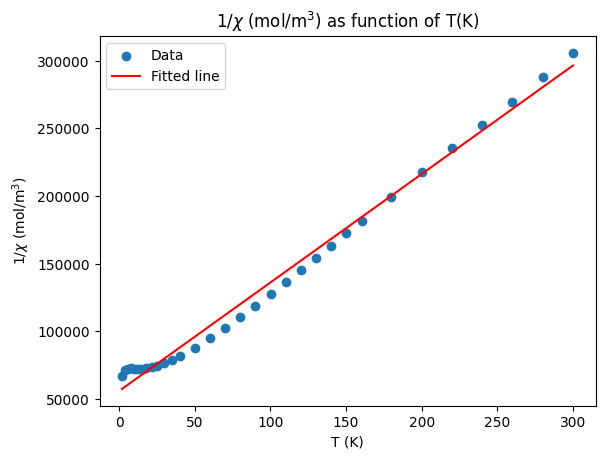

In [7]:
plt.scatter(data1['K'], data1['1/x_mol/m^3'], label='Data')
plt.plot(data1['K'], m*data1['K']+b, 'r', label='Fitted line')
plt.title(r'1/$\chi$ (mol/m$^3$) as function of T(K)')
plt.ylabel(r'1/$\chi$ (mol/m$^3$)')
plt.xlabel('T (K)')
plt.legend()

In [8]:
#calculando C y Theta
# since m = 1/C, then
C = 1/m
# since b = -Theta/C, then
Theta = -b*C
print(f"C = {C} (m^3*K/mol) \n\u0398 = {Theta} (K)")

C = 0.0012462214646805905 (m^3*K/mol) 
Θ = -69.55229667181271 (K)


In [9]:
# C esta en [m^3.K/mol]
C_V = C/2
print(f"C_V = {C_V} (m^3*K/mol_V)")

C_V = 0.0006231107323402952 (m^3*K/mol_V)


arreglar las constantes

In [10]:
#calculating mu in SI
# using C=mu-0*N*mu^2/3k
# setting the constant values
k = 1.380649e-23 # [J/K]
mu_0 = 1.25663706127e-6 # [N/A^2]
N_A = 6.02214076e23 # [mol^-1] de V
mu = np.sqrt((3*k*C)/(mu_0*N_A)) # [] 
mu # [m^2.A]
print(f"\u03BC = {mu} (m^2*A)")

μ = 2.6116772087020533e-22 (m^2*A)


In [11]:
#calculating mu_eff
mu_B = 9.2740100657e-24# [J/T]
mu_eff = mu/mu_B
mu_eff
print(f'\u03BC_eff = {mu_eff}')

μ_eff = 28.1612505291682
